# MTZ / Validation Map Coefficients → VoxBind Density Crop

Downloads 2Fo-Fc and Fo-Fc map coefficient CIF files from RCSB validation reports,
converts them to CCP4 maps, crops a 64³ × 0.25 Å box around the pocket ligand centroid,
and compares with the existing pre-computed CCP4 map (if available).

| Section | Contents |
|---|---|
| 1. Config | PDB ID, dirs, pocket SDF path |
| 2. Download & convert | CIF.gz → CCP4 via gemmi |
| 3. (Optional) MTZ | Load a local `.mtz` file directly |
| 4. Crop | 64³ VoxBind crop around ligand centroid |
| 5. Statistics | Per-map distribution + comparison |
| 6. 2D slices | Orthogonal slice overlaid with pocket atoms |
| 7. 3D scatter | Interactive Plotly: density + pocket + ligand |
| 8. Compare maps | 2Fo-Fc vs Fo-Fc vs existing CCP4 side-by-side |

In [1]:
import os, gzip, math, re
from pathlib import Path

import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import requests
import gemmi
import torch

from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print('Imports OK')

Imports OK


## 1. Config

In [2]:
PDB_ID     = '5p9s'   # ← change to your PDB ID

MAP_DIR    = Path('maps')                       # where CIF / CCP4 files are saved
DATA_DIR   = Path('../voxbind/dataset/data')
CCP4_DIR   = DATA_DIR / 'ccp4'                 # existing pre-computed maps
CROPS_DIR  = DATA_DIR / 'xray_crops' / 'train' # pre-computed 64³ crops

# CrossDocked pocket/ligand SDF — set to None to auto-detect from dataset
POCKET_PDB = None
LIGAND_SDF = None

# VoxBind grid constants
GRID_DIM   = 64
VOXEL_RES  = 0.25   # Å/voxel
HALF       = GRID_DIM * VOXEL_RES / 2   # 8 Å

MAP_DIR.mkdir(exist_ok=True)
print(f'PDB ID  : {PDB_ID}')
print(f'Map dir : {MAP_DIR.resolve()}')

PDB ID  : 5p9s
Map dir : /home/shpark/prj-ligand/Voxbind/notebook/maps


### 1b. Auto-find pocket/ligand from CrossDocked dataset (optional)

In [3]:
# Scan crossdocked_pocket10 for a PDB file matching PDB_ID
pocket10_dir = DATA_DIR / 'crossdocked_pocket10'

if POCKET_PDB is None or LIGAND_SDF is None:
    found_pdbs = sorted(pocket10_dir.rglob(f'*{PDB_ID}*pocket10.pdb'))
    found_sdfs = sorted(pocket10_dir.rglob(f'*{PDB_ID}*.sdf'))

    if found_pdbs:
        POCKET_PDB = found_pdbs[0]
        print(f'pocket PDB : {POCKET_PDB}')
    else:
        print(f'WARNING: no pocket PDB found for {PDB_ID} — set POCKET_PDB manually')

    if found_sdfs:
        LIGAND_SDF = found_sdfs[0]
        print(f'ligand SDF : {LIGAND_SDF}')
    else:
        print(f'WARNING: no ligand SDF found for {PDB_ID} — set LIGAND_SDF manually')
else:
    POCKET_PDB = Path(POCKET_PDB)
    LIGAND_SDF = Path(LIGAND_SDF)

pocket PDB : ../voxbind/dataset/data/crossdocked_pocket10/COMT_MOUSE_44_264_0/1h1d_A_rec_5p9s_sah_lig_tt_docked_0_pocket10.pdb
ligand SDF : ../voxbind/dataset/data/crossdocked_pocket10/COMT_MOUSE_44_264_0/1h1d_A_rec_5p9s_sah_lig_tt_docked_0.sdf


## 2. Download validation map coefficients and convert to CCP4

In [4]:
def download_map_coefficients(pdb_id, output_dir=MAP_DIR):
    """Download 2Fo-Fc and Fo-Fc validation map coefficient CIF files from RCSB."""
    pdb_id = pdb_id.lower()
    hash_dir = pdb_id[1:3]
    base_url = f'https://files.rcsb.org/pub/pdb/validation_reports/{hash_dir}/{pdb_id}'

    files = {
        '2fofc': f'{pdb_id}_validation_2fo-fc_map_coef.cif.gz',
        'fofc':  f'{pdb_id}_validation_fo-fc_map_coef.cif.gz',
    }

    paths = {}
    for key, fname in files.items():
        out_cif = output_dir / fname.replace('.gz', '')
        if out_cif.exists():
            print(f'  [{key}] already exists → {out_cif}')
            paths[key] = out_cif
            continue

        url = f'{base_url}/{fname}'
        r = requests.get(url, timeout=30)
        if r.status_code != 200:
            print(f'  [{key}] not available (HTTP {r.status_code})')
            continue

        out_gz = output_dir / fname
        out_gz.write_bytes(r.content)
        with gzip.open(out_gz, 'rb') as gz, open(out_cif, 'wb') as f:
            f.write(gz.read())
        out_gz.unlink()

        paths[key] = out_cif
        print(f'  [{key}] → {out_cif}')

    return paths


def cif_to_ccp4(cif_path, output_map_path, map_type='2fofc'):
    """Convert map coefficient CIF to CCP4 map using gemmi."""
    doc     = gemmi.cif.read(str(cif_path))
    rblocks = gemmi.as_refln_blocks(doc)
    if not rblocks:
        raise ValueError(f'No reflection blocks found in {cif_path}')

    rb = rblocks[0]
    if map_type == '2fofc':
        col_f, col_phi = 'pdbx_FWT', 'pdbx_PHWT'
    else:
        col_f, col_phi = 'pdbx_DELFWT', 'pdbx_DELPHWT'

    grid = rb.transform_f_phi_to_map(col_f, col_phi, sample_rate=3.0)

    ccp4 = gemmi.Ccp4Map()
    ccp4.grid = grid
    ccp4.update_ccp4_header()
    ccp4.write_ccp4_map(str(output_map_path))
    print(f'  Wrote {output_map_path}')
    return output_map_path

In [5]:
print(f'Downloading map coefficients for {PDB_ID} ...')
cif_paths = download_map_coefficients(PDB_ID)

ccp4_paths = {}
for key, cif in cif_paths.items():
    out = MAP_DIR / f'{PDB_ID}_{key}.ccp4'
    if out.exists():
        print(f'  [{key}] CCP4 already exists → {out}')
        ccp4_paths[key] = out
    else:
        print(f'  [{key}] converting CIF → CCP4 ...')
        ccp4_paths[key] = cif_to_ccp4(cif, out, map_type=key)

# Also note the existing CCP4 from downloads (if present)
existing_ccp4 = CCP4_DIR / f'{PDB_ID}.map'
if existing_ccp4.exists():
    ccp4_paths['existing'] = existing_ccp4
    print(f'  [existing] found pre-downloaded map → {existing_ccp4}')

print(f'\nAvailable maps: {list(ccp4_paths.keys())}')

  [2fofc] → maps/5p9s_validation_2fo-fc_map_coef.cif
  [fofc] → maps/5p9s_validation_fo-fc_map_coef.cif
  [2fofc] converting CIF → CCP4 ...
  Wrote maps/5p9s_2fofc.ccp4
  [fofc] converting CIF → CCP4 ...
  Wrote maps/5p9s_fofc.ccp4
  [existing] found pre-downloaded map → ../voxbind/dataset/data/ccp4/5p9s.map

Available maps: ['2fofc', 'fofc', 'existing']


## 3. (Optional) Load a local MTZ file directly

Skip this cell if you only have the CIF/CCP4 maps from section 2.

In [6]:
MTZ_PATH = None   # ← set to Path('your_file.mtz') to use a local MTZ

if MTZ_PATH is not None:
    MTZ_PATH = Path(MTZ_PATH)
    mtz = gemmi.read_mtz_file(str(MTZ_PATH))
    print(f'MTZ columns: {[c.label for c in mtz.columns]}')

    # Find F/PHI column pairs — adjust labels to match your file
    # Common: 2FOFCWT/PH2FOFCWT  or  FWT/PHWT  or  2mFo-DFc/P2mFo-DFc
    f_col   = next((c.label for c in mtz.columns
                    if any(k in c.label for k in ('FWT', '2FOFCWT', '2mFo'))), None)
    phi_col = next((c.label for c in mtz.columns
                    if any(k in c.label for k in ('PHWT', 'PH2FOFCWT', 'P2mFo'))), None)

    print(f'Using F={f_col}  PHI={phi_col}')

    grid_mtz = mtz.transform_f_phi_to_map(f_col, phi_col, sample_rate=3.0)
    ccp4_mtz = gemmi.Ccp4Map()
    ccp4_mtz.grid = grid_mtz
    ccp4_mtz.update_ccp4_header()

    mtz_out = MAP_DIR / f'{PDB_ID}_mtz_2fofc.ccp4'
    ccp4_mtz.write_ccp4_map(str(mtz_out))
    ccp4_paths['mtz_2fofc'] = mtz_out
    print(f'Wrote {mtz_out}')
else:
    print('No MTZ file set — skipping (set MTZ_PATH above to use a local .mtz)')

No MTZ file set — skipping (set MTZ_PATH above to use a local .mtz)


## 4. Load pocket / ligand and compute centroid

In [7]:
ELEM_COLOR = {'C': 'silver', 'N': 'cornflowerblue', 'O': 'tomato',
              'S': 'gold',   'F': 'limegreen',       'Cl': 'lime', 'P': 'orange'}

# ── Ligand centroid ───────────────────────────────────────────────────────────
assert LIGAND_SDF is not None and LIGAND_SDF.exists(), \
    f'LIGAND_SDF not found: {LIGAND_SDF}'

suppl   = Chem.SDMolSupplier(str(LIGAND_SDF), removeHs=True)
lig_mol = next((m for m in suppl if m is not None), None)
assert lig_mol is not None, f'Could not parse ligand from {LIGAND_SDF}'

lig_xyz = np.array(lig_mol.GetConformer().GetPositions(), dtype=np.float64)
lig_elem= [a.GetSymbol() for a in lig_mol.GetAtoms()]
centroid = lig_xyz.mean(axis=0)
ref_smi  = Chem.MolToSmiles(lig_mol)

print(f'Ligand SDF      : {LIGAND_SDF.name}')
print(f'Ligand SMILES   : {ref_smi}')
print(f'Ligand atoms    : {len(lig_xyz)}')
print(f'Centroid (Å)    : {centroid.round(3)}')

# ── Pocket atoms ──────────────────────────────────────────────────────────────
poc_xyz, poc_elem = [], []
if POCKET_PDB is not None and POCKET_PDB.exists():
    for line in POCKET_PDB.read_text().splitlines():
        if not (line.startswith('ATOM') or line.startswith('HETATM')):
            continue
        try:
            x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
        except ValueError:
            continue
        elem = line[76:78].strip() if len(line) > 76 else ''
        if not elem:
            elem = re.sub(r'[^A-Za-z]', '', line[12:16]).strip()[:2].capitalize()
        if elem in ('H', 'D'):
            continue
        poc_xyz.append([x, y, z])
        poc_elem.append(elem)
    poc_xyz = np.array(poc_xyz, dtype=np.float64)
    print(f'Pocket PDB      : {POCKET_PDB.name}  ({len(poc_xyz)} atoms)')
else:
    poc_xyz  = np.empty((0, 3))
    poc_elem = []
    print('WARNING: no pocket PDB loaded')

Ligand SDF      : 1h1d_A_rec_5p9s_sah_lig_tt_docked_0.sdf
Ligand SMILES   : Nc1ncnc2c1ncn2[C@@H]1O[C@H](CSCC[C@H](N)C(=O)O)[C@@H](O)[C@H]1O
Ligand atoms    : 26
Centroid (Å)    : [-2.745 21.111 13.63 ]
Pocket PDB      : 1h1d_A_rec_5p9s_sah_lig_tt_docked_0_pocket10.pdb  (457 atoms)


## 4. Crop density maps to 64³ VoxBind grid

In [8]:
def load_and_crop(ccp4_path, center_cart, G=GRID_DIM, res=VOXEL_RES):
    """Load a CCP4 map and crop a G³ box centred on center_cart.
    Returns (crop_norm, raw_sigma) where crop_norm is locally z-scored."""
    m = gemmi.read_ccp4_map(str(ccp4_path))
    m.setup(float('nan'))
    grid = m.grid
    cell = grid.unit_cell

    arr  = np.array(grid, dtype=np.float32)
    nu, nv, nw = arr.shape
    sigma_global = arr.std()
    if sigma_global < 1e-10:
        return None, None
    arr_norm = (arr - arr.mean()) / sigma_global

    # Fractionalization matrix
    orth_mat = np.array(cell.orth.mat.tolist())
    frac_T   = np.linalg.inv(orth_mat).T   # (3,3): x @ frac_T = fractional

    # Build G³ query grid in Cartesian Å
    offsets = (np.arange(G, dtype=np.float32) - G * 0.5) * res
    gx, gy, gz = np.meshgrid(
        offsets + center_cart[0],
        offsets + center_cart[1],
        offsets + center_cart[2],
        indexing='ij',
    )
    cart_pts = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=1)

    # Cartesian → fractional → CCP4 grid indices (periodic)
    frac_pts = cart_pts @ frac_T
    ci = (frac_pts[:, 0] * nu) % nu
    cj = (frac_pts[:, 1] * nv) % nv
    ck = (frac_pts[:, 2] * nw) % nw

    crop = scipy.ndimage.map_coordinates(
        arr_norm, [ci, cj, ck], order=1, mode='wrap', prefilter=False
    ).reshape(G, G, G).astype(np.float32)

    # Local z-score with ±3σ clip (same as crossdocked_xray.normalize_crop)
    mu, sigma_local = crop.mean(), crop.std()
    if sigma_local > 1e-10:
        crop_clipped = np.clip(crop, mu - 3.0 * sigma_local, mu + 3.0 * sigma_local)
        crop_norm = (crop_clipped - mu) / sigma_local
    else:
        crop_norm = crop - mu

    return crop_norm, sigma_global


print('Crop function defined.')

Crop function defined.


In [9]:
crops = {}   # label → (crop_norm, sigma_global)

for label, path in ccp4_paths.items():
    print(f'  [{label}] cropping {path.name} ...')
    crop, sigma = load_and_crop(path, centroid)
    if crop is None:
        print(f'    WARNING: empty/flat map — skipped')
        continue
    crops[label] = (crop, sigma)
    print(f'    mean={crop.mean():.4f}  std={crop.std():.4f}  '
          f'global_sigma={sigma:.4f}')

# Also load pre-computed crop from CROPS_DIR if available
# (requires knowing the dataset index — set manually if desired)
SAMPLE_IDX = None   # ← set to the dataset index to compare with pre-computed crop
if SAMPLE_IDX is not None:
    crop_npy = CROPS_DIR / f'{SAMPLE_IDX:06d}.npy'
    if crop_npy.exists():
        precomp = np.load(str(crop_npy)).astype(np.float32)
        crops['precomputed'] = (precomp, None)
        print(f'  [precomputed] loaded {crop_npy}  '
              f'mean={precomp.mean():.4f}  std={precomp.std():.4f}')

print(f'\nLoaded crops: {list(crops.keys())}')

  [2fofc] cropping 5p9s_2fofc.ccp4 ...
    mean=-0.0002  std=0.9993  global_sigma=0.1903
  [fofc] cropping 5p9s_fofc.ccp4 ...
    mean=-0.0008  std=0.9947  global_sigma=0.0765
  [existing] cropping 5p9s.map ...
    mean=-0.0002  std=0.9994  global_sigma=0.1901

Loaded crops: ['2fofc', 'fofc', 'existing']


## 5. Crop statistics

Label               mean       std       min       max     >1σ (%)     >2σ (%)
---------------------------------------------------------------------------
2fofc            -0.0002    0.9993   -2.1646    3.0000        18.2         4.4
fofc             -0.0008    0.9947   -3.0000    3.0000        15.3         2.7
existing         -0.0002    0.9994   -2.4306    3.0000        18.0         4.1


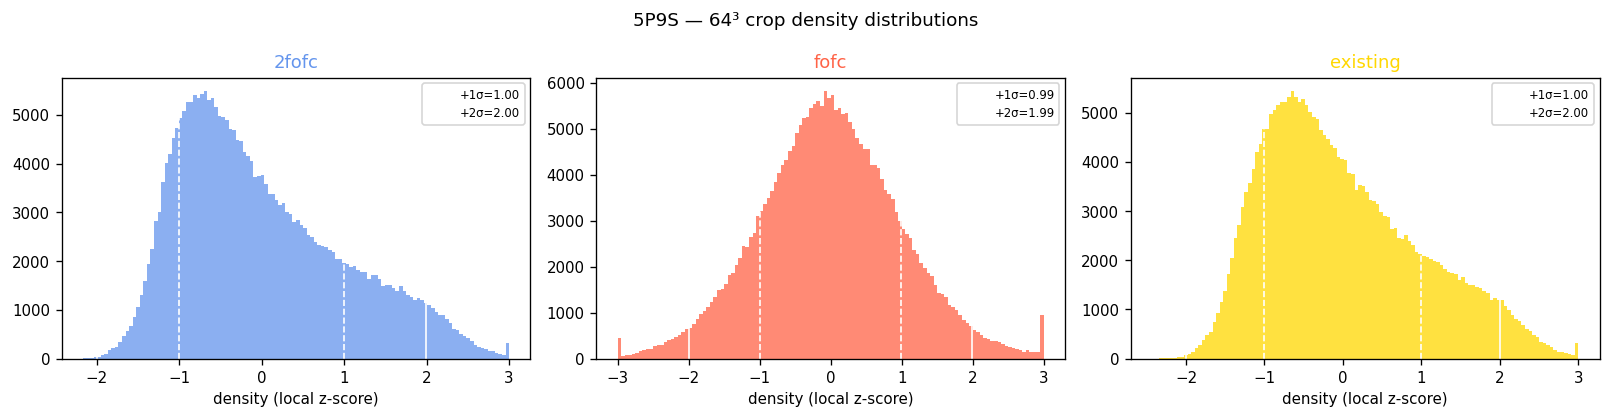

In [10]:
COND_COLOR = {
    '2fofc':       'cornflowerblue',
    'fofc':        'tomato',
    'existing':    'gold',
    'mtz_2fofc':   'mediumorchid',
    'precomputed': 'limegreen',
}

n_maps = len(crops)
fig, axes = plt.subplots(1, n_maps, figsize=(4.5 * n_maps, 3.5), sharey=False)
if n_maps == 1:
    axes = [axes]

print(f'{'Label':<14}  {'mean':>8}  {'std':>8}  {'min':>8}  {'max':>8}  '
      f'{'>1σ (%)':>10}  {'>2σ (%)':>10}')
print('-' * 75)

for ax, (label, (crop, _)) in zip(axes, crops.items()):
    flat   = crop.ravel()
    mu     = flat.mean()
    sigma  = flat.std()
    above1 = 100 * (flat > mu + sigma).mean()
    above2 = 100 * (flat > mu + 2 * sigma).mean()
    print(f'{label:<14}  {mu:>8.4f}  {sigma:>8.4f}  '
          f'{flat.min():>8.4f}  {flat.max():>8.4f}  '
          f'{above1:>10.1f}  {above2:>10.1f}')

    color = COND_COLOR.get(label, 'steelblue')
    ax.hist(flat, bins=120, color=color, alpha=0.75, edgecolor='none')
    for k, ls in [(1, '--'), (2, '-')]:
        ax.axvline(mu + k * sigma, color='white', ls=ls, lw=1,
                   label=f'+{k}σ={mu+k*sigma:.2f}')
        ax.axvline(mu - k * sigma, color='white', ls=ls, lw=1)
    ax.set_title(label, color=color)
    ax.set_xlabel('density (local z-score)')
    ax.legend(fontsize=7)

plt.suptitle(f'{PDB_ID.upper()} — 64³ crop density distributions', fontsize=11)
plt.tight_layout()
plt.show()

## 6. 2D orthogonal slices through ligand centroid

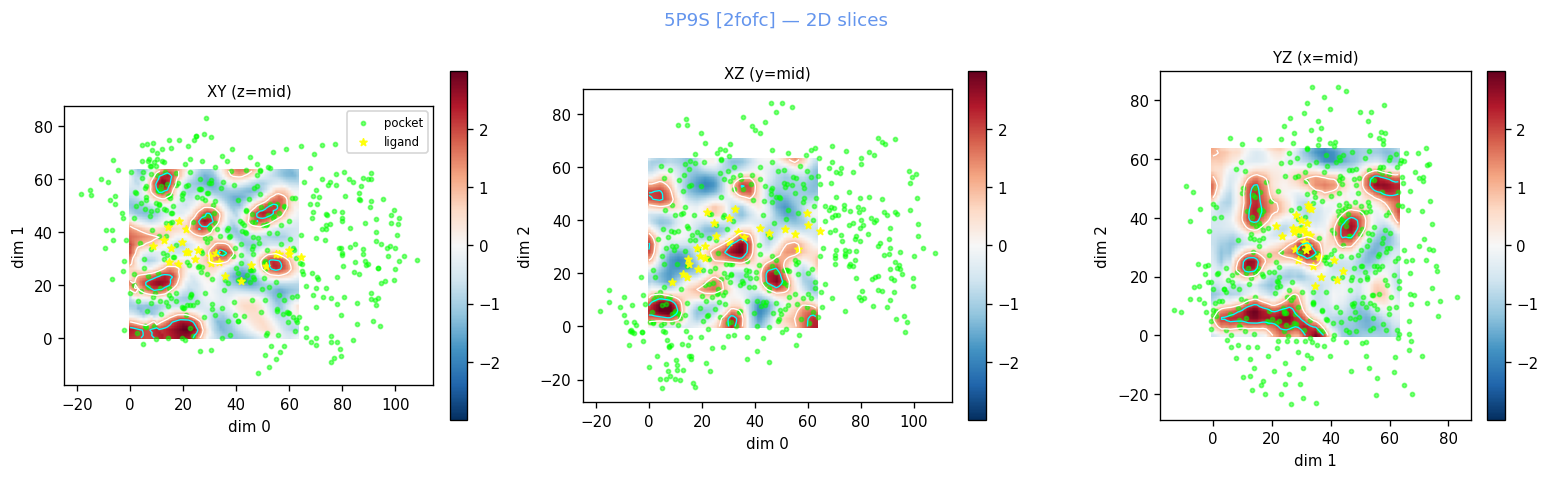

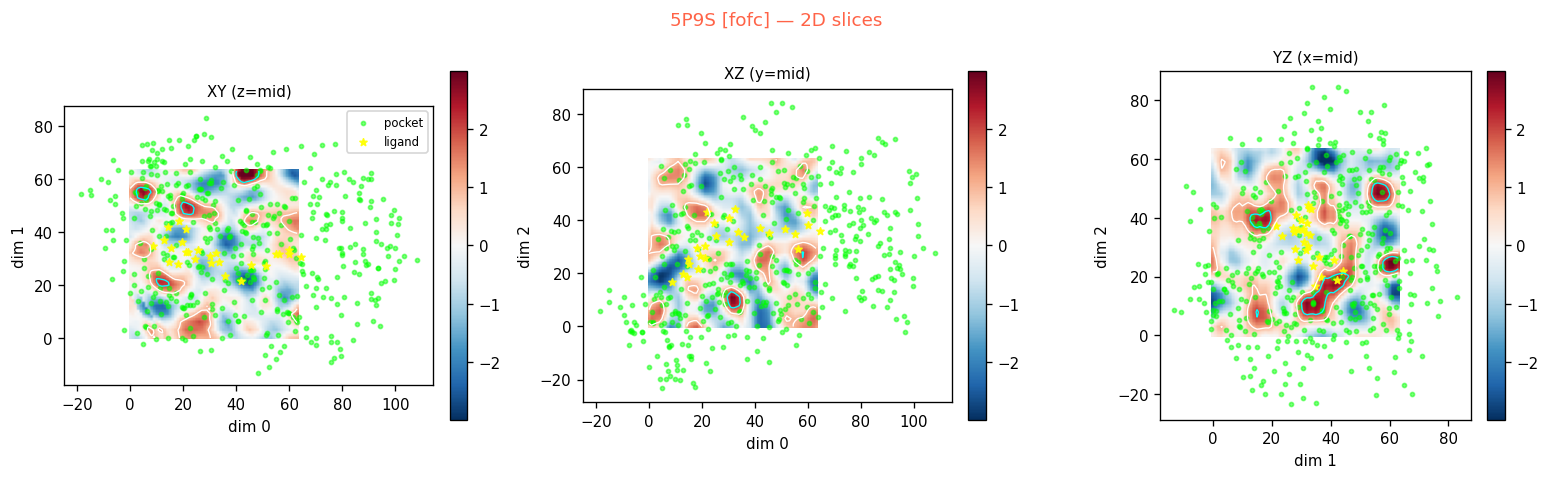

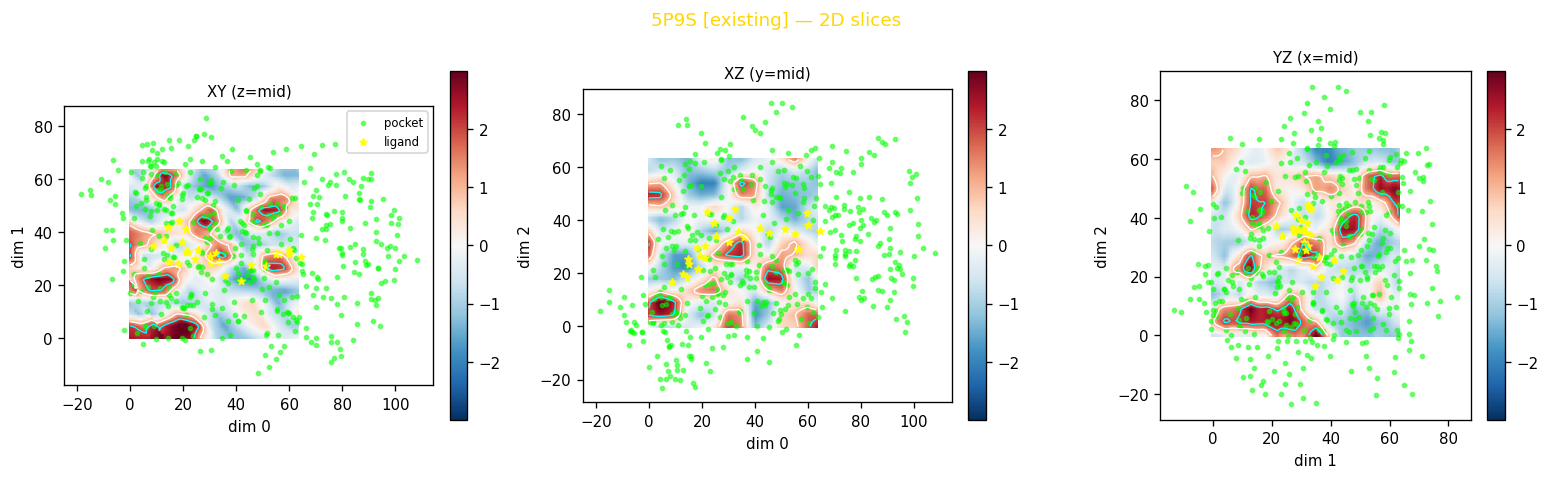

In [11]:
# Pocket atoms relative to centroid, in voxel units
if len(poc_xyz) > 0:
    poc_rel_A  = poc_xyz - centroid                   # Å, origin at centroid
    poc_rel_vox = poc_rel_A / VOXEL_RES + GRID_DIM / 2  # voxel coords in 64³
else:
    poc_rel_vox = np.empty((0, 3))

mid = GRID_DIM // 2   # slice through centre of the crop

for label, (crop, _) in crops.items():
    mu, sigma = crop.mean(), crop.std()
    vmin, vmax = mu - 3 * sigma, mu + 3 * sigma
    color = COND_COLOR.get(label, 'steelblue')

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    slice_specs = [
        ('XY (z=mid)', crop[:, :, mid], 0, 1),
        ('XZ (y=mid)', crop[:, mid, :], 0, 2),
        ('YZ (x=mid)', crop[mid, :, :], 1, 2),
    ]
    for ax, (title, slc, dim_x, dim_y) in zip(axes, slice_specs):
        im = ax.imshow(slc.T, origin='lower', cmap='RdBu_r',
                       vmin=vmin, vmax=vmax, aspect='equal')
        ax.contour(slc.T, levels=[mu + 1.0 * sigma],
                   colors=['white'], linewidths=0.8)
        ax.contour(slc.T, levels=[mu + 2.0 * sigma],
                   colors=['cyan'], linewidths=0.8)
        # Pocket atoms
        if len(poc_rel_vox) > 0:
            ax.scatter(poc_rel_vox[:, dim_x], poc_rel_vox[:, dim_y],
                       c='lime', s=6, alpha=0.5, label='pocket')
        # Ligand atoms
        lig_vox = (lig_xyz - centroid) / VOXEL_RES + GRID_DIM / 2
        ax.scatter(lig_vox[:, dim_x], lig_vox[:, dim_y],
                   c='yellow', s=20, marker='*', alpha=0.9, label='ligand')
        ax.set_title(title, fontsize=9)
        ax.set_xlabel(f'dim {dim_x}')
        ax.set_ylabel(f'dim {dim_y}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    axes[0].legend(fontsize=7)
    fig.suptitle(f'{PDB_ID.upper()} [{label}] — 2D slices', color=color, fontsize=11)
    plt.tight_layout()
    plt.show()

## 7. Interactive 3D scatter — density + pocket + ligand

Select which map to visualise with `SHOW_LABEL`.

In [12]:
SHOW_LABEL     = '2fofc'   # ← choose from crops.keys()
DENSITY_THRESH = 1.0       # σ level to show

assert SHOW_LABEL in crops, f'{SHOW_LABEL!r} not in {list(crops.keys())}'
crop, _ = crops[SHOW_LABEL]
mu, sigma = crop.mean(), crop.std()

# Cartesian coordinates of each voxel (relative to centroid)
offsets = (np.arange(GRID_DIM, dtype=np.float32) - GRID_DIM * 0.5) * VOXEL_RES
gi, gj, gk = np.meshgrid(offsets, offsets, offsets, indexing='ij')
flat_vals = crop.ravel()

dmask = flat_vals > mu + DENSITY_THRESH * sigma
Xd, Yd, Zd = gi.ravel()[dmask], gj.ravel()[dmask], gk.ravel()[dmask]
vals = flat_vals[dmask]
clim = 2.0 * sigma

traces = []

# Density
traces.append(go.Scatter3d(
    x=Xd, y=Yd, z=Zd, mode='markers',
    marker=dict(size=2, color=vals, colorscale='Blues',
                cmin=mu + DENSITY_THRESH * sigma, cmax=mu + clim,
                opacity=0.4,
                colorbar=dict(title='ρ', thickness=12, len=0.5,
                              tickfont=dict(color='white'))),
    name=f'density >{DENSITY_THRESH}σ ({dmask.sum():,} pts)',
))

# Pocket atoms
if len(poc_xyz) > 0:
    poc_rel = poc_xyz - centroid
    in_box  = np.all(np.abs(poc_rel) <= HALF, axis=1)
    for elem in sorted(set(e for e, m in zip(poc_elem, in_box) if m)):
        mask_e = np.array([e == elem and m for e, m in zip(poc_elem, in_box)])
        xyz_e  = poc_rel[mask_e]
        traces.append(go.Scatter3d(
            x=xyz_e[:, 0], y=xyz_e[:, 1], z=xyz_e[:, 2],
            mode='markers',
            marker=dict(size=4, color=ELEM_COLOR.get(elem, 'purple'), opacity=0.7),
            name=f'pocket {elem}',
        ))

# Ligand atoms
lig_rel = lig_xyz - centroid
traces.append(go.Scatter3d(
    x=lig_rel[:, 0], y=lig_rel[:, 1], z=lig_rel[:, 2],
    mode='markers',
    marker=dict(size=8, color='yellow', symbol='diamond', opacity=0.95,
                line=dict(width=1, color='white')),
    name='ref ligand',
))

# Bounding box wireframe
B = HALF
corners = np.array([[-B,-B,-B],[-B,-B,B],[-B,B,-B],[-B,B,B],
                    [ B,-B,-B],[ B,-B,B],[ B,B,-B],[ B,B,B]])
edges = [(0,1),(0,2),(1,3),(2,3),(4,5),(4,6),(5,7),(6,7),(0,4),(1,5),(2,6),(3,7)]
xs, ys, zs = [], [], []
for i, j in edges:
    xs += [corners[i,0], corners[j,0], None]
    ys += [corners[i,1], corners[j,1], None]
    zs += [corners[i,2], corners[j,2], None]
traces.append(go.Scatter3d(
    x=xs, y=ys, z=zs, mode='lines',
    line=dict(color='white', width=1, dash='dash'),
    name=f'grid ±{B:.0f}Å',
))

fig = go.Figure(traces)
fig.update_layout(
    title=f'{PDB_ID.upper()} [{SHOW_LABEL}] — density >{DENSITY_THRESH}σ + pocket + ligand',
    scene=dict(
        xaxis_title='ΔX (Å)', yaxis_title='ΔY (Å)', zaxis_title='ΔZ (Å)',
        aspectmode='cube', bgcolor='rgb(15,15,15)',
        xaxis=dict(showbackground=False, range=[-B-1, B+1]),
        yaxis=dict(showbackground=False, range=[-B-1, B+1]),
        zaxis=dict(showbackground=False, range=[-B-1, B+1]),
    ),
    paper_bgcolor='rgb(25,25,25)', font_color='white',
    legend=dict(x=0.01, y=0.99, font_color='white'),
    width=950, height=800,
)
fig.show()
print(f'Density points shown: {dmask.sum():,} / {crop.size:,}')

Density points shown: 47,617 / 262,144


## 8. Side-by-side map comparison

Compare 2Fo-Fc, Fo-Fc, and existing CCP4 crops on the same XY slice.

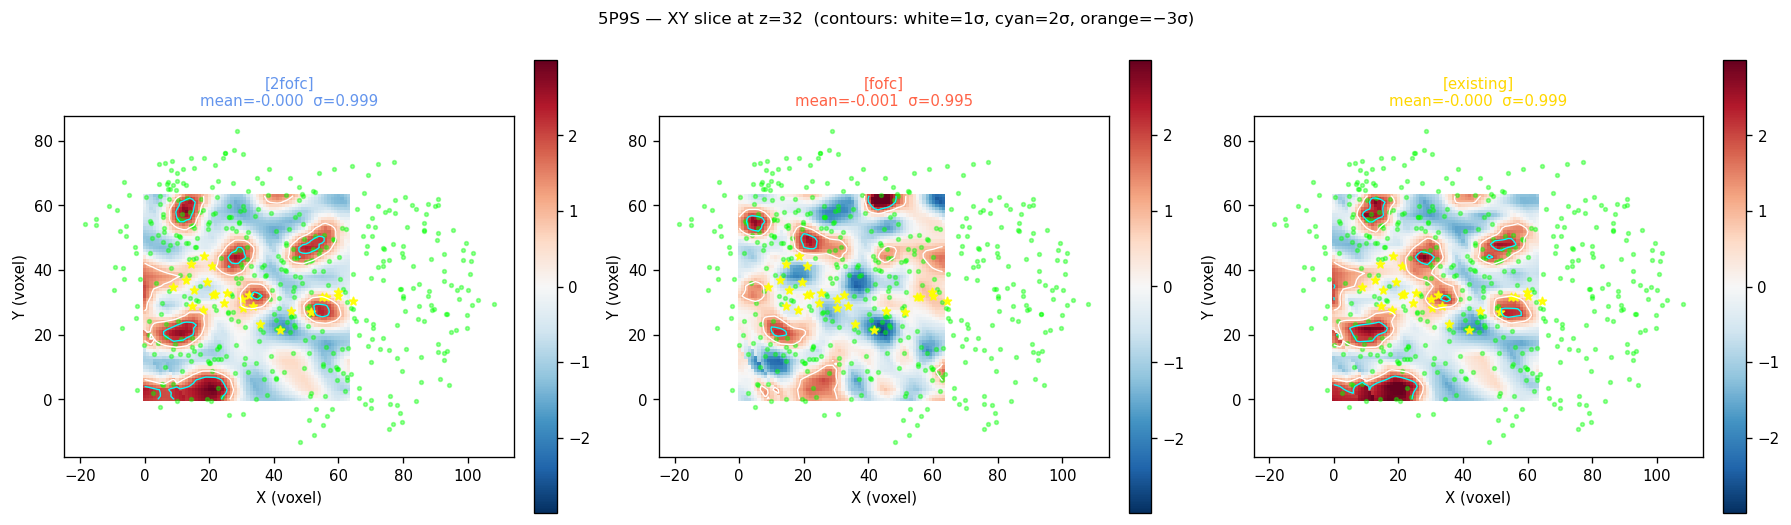

In [13]:
mid = GRID_DIM // 2
n   = len(crops)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
if n == 1:
    axes = [axes]

lig_vox = (lig_xyz - centroid) / VOXEL_RES + GRID_DIM / 2

for ax, (label, (crop, _)) in zip(axes, crops.items()):
    mu, sigma = crop.mean(), crop.std()
    slc  = crop[:, :, mid]
    color = COND_COLOR.get(label, 'steelblue')

    im = ax.imshow(slc.T, origin='lower', cmap='RdBu_r',
                   vmin=mu - 3 * sigma, vmax=mu + 3 * sigma, aspect='equal')
    ax.contour(slc.T, levels=[mu + 1.0 * sigma], colors=['white'],   linewidths=0.8)
    ax.contour(slc.T, levels=[mu + 2.0 * sigma], colors=['cyan'],    linewidths=0.8)
    ax.contour(slc.T, levels=[mu - 3.0 * sigma], colors=['orange'],  linewidths=0.8,
               linestyles='dashed')

    if len(poc_xyz) > 0:
        ax.scatter(poc_rel_vox[:, 0], poc_rel_vox[:, 1],
                   c='lime', s=5, alpha=0.4)
    ax.scatter(lig_vox[:, 0], lig_vox[:, 1],
               c='yellow', s=25, marker='*', alpha=0.9)

    ax.set_title(f'[{label}]\nmean={mu:.3f}  σ={sigma:.3f}',
                 color=color, fontsize=9)
    ax.set_xlabel('X (voxel)')
    ax.set_ylabel('Y (voxel)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'{PDB_ID.upper()} — XY slice at z={mid}  (contours: white=1σ, cyan=2σ, orange=−3σ)',
             fontsize=10)
plt.tight_layout()
plt.show()

## 9. Load crop into VoxBind pipeline

Demonstrates how to pass the crop as a density tensor to the model,
mirroring what `DatasetCrossDockedXray` does at training/inference time.

In [14]:
import sys
sys.path.insert(0, str(Path('..') / 'voxbind'))

from voxbind.dataset.crossdocked_xray import normalize_crop

MAP_TO_USE = '2fofc'   # ← pick which map to feed to the model

assert MAP_TO_USE in crops, f'{MAP_TO_USE!r} not available'
crop_np, _ = crops[MAP_TO_USE]

# normalize_crop applies local ±3σ clip + z-score (same as dataset __getitem__)
crop_norm = normalize_crop(crop_np)
density_tensor = torch.from_numpy(crop_norm).unsqueeze(0).unsqueeze(0)  # (1,1,64,64,64)

print(f'Density tensor shape : {tuple(density_tensor.shape)}')
print(f'  mean  = {density_tensor.mean():.4f}')
print(f'  std   = {density_tensor.std():.4f}')
print(f'  min   = {density_tensor.min():.4f}')
print(f'  max   = {density_tensor.max():.4f}')
print()
print('Ready to pass as `density=density_tensor.cuda()` to wjs_sample() or model.forward()')

Density tensor shape : (1, 1, 64, 64, 64)
  mean  = -0.0000
  std   = 1.0000
  min   = -2.1659
  max   = 3.0000

Ready to pass as `density=density_tensor.cuda()` to wjs_sample() or model.forward()
